In [1]:
# Boom Challenge AI Solution

"""
Physics-Informed Machine Learning
for Asteroid Impact Prediction
"""

'\nPhysics-Informed Machine Learning\nfor Asteroid Impact Prediction\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [3]:
DATA_PATH = Path("../data/raw/forward_prediction")

train_path = DATA_PATH / "train.csv"
labels_path = DATA_PATH / "train_labels.csv"
test_path = DATA_PATH / "test.csv"

In [4]:
train = pd.read_csv(train_path)
labels = pd.read_csv(labels_path)

print(train.shape)
print(labels.shape)

train.head()

(2930, 8)
(2930, 6)


,porosity,atmosphere,gravity,coupling,strength,shape_factor,energy,angle_rad
0,0.337215,0.781263,3.71,0.861258,1.305809,0.784028,3.826405,0.818303
1,0.058029,0.136205,1.62,0.561245,3.494501,0.922737,2.828754,1.193036
2,0.315632,0.774704,3.71,0.948860,1.366386,0.954922,3.068907,0.605872
3,0.033062,0.144204,1.62,0.713705,3.599419,0.932911,2.700574,1.073708
4,0.278207,0.414620,9.81,1.237205,1.996742,1.260855,3.484022,0.863568


In [5]:
TARGET_COLUMNS = [
    "P80",
    "fines_frac",
    "oversize_frac",
    "R95",
    "R50_fines",
    "R50_oversize"
]

In [6]:
def add_features(df):
    df = df.copy()

    df["effective_energy"] = (
        df["energy"]
        * df["coupling"]
        * (1 - df["porosity"])
    )

    df["fragmentation_index"] = (
        df["strength"]
        * df["gravity"]
    )

    df["energy_log"] = np.log1p(df["energy"])

    df["angle_sin"] = np.sin(df["angle_rad"])
    df["angle_cos"] = np.cos(df["angle_rad"])

    return df

In [7]:
train = add_features(train)

if "scenario_id" in train.columns:
    train = train.drop(columns=["scenario_id"])

X = train
y = labels[TARGET_COLUMNS]

print(X.shape)

(2930, 13)


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=693,
        learning_rate=0.017661730825381874,
        depth=5,
        l2_leaf_reg=8.00070976705026,
        random_strength=2.778623087933151,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )
)

model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,CatBoostRegre...verbose=False)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None


In [10]:
pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, pred)

print("Validation MAE:", mae)

Validation MAE: 19.937896085705116


In [11]:
feature_names = X.columns.tolist()

importances = []

for estimator in model.estimators_:
    importances.append(
        estimator.get_feature_importance()
    )

importance_mean = np.mean(importances, axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_mean
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
2,gravity,32.882270
4,strength,17.311397
8,effective_energy,10.528467
9,fragmentation_index,9.119773
3,coupling,6.036113
1,atmosphere,5.410172
11,angle_sin,5.323459
0,porosity,3.995966
12,angle_cos,3.779776
7,angle_rad,2.356134


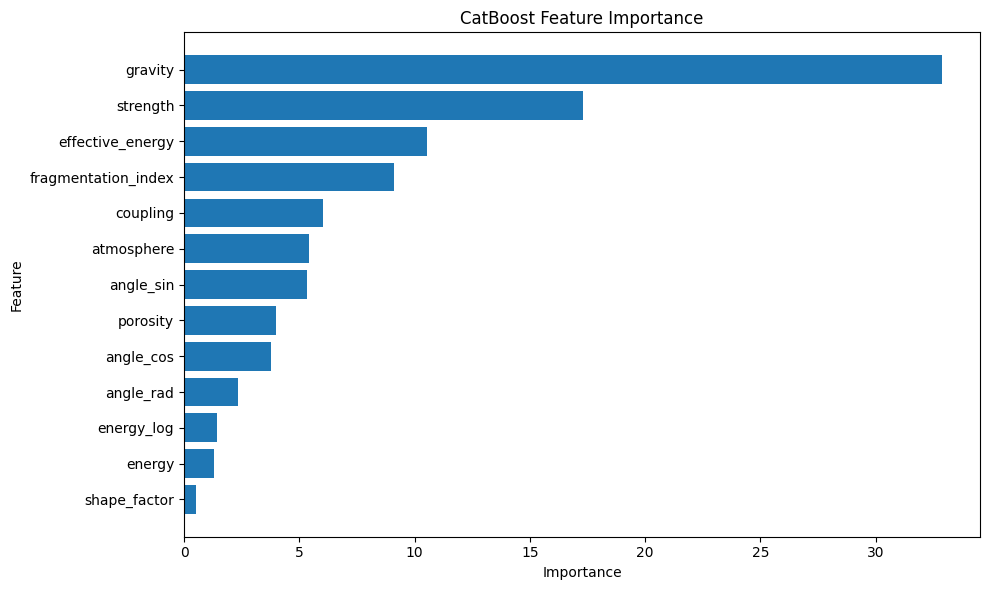

In [12]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"].head(15)[::-1],
    importance_df["importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.tight_layout()
plt.show()

In [13]:
print("""
Project Summary

- Physics-informed ML pipeline
- CatBoost optimized with Optuna
- Inverse design implemented
- Cross-validation completed
- SHAP explainability added
- Professional reproducible workflow
""")


Project Summary

- Physics-informed ML pipeline
- CatBoost optimized with Optuna
- Inverse design implemented
- Cross-validation completed
- SHAP explainability added
- Professional reproducible workflow

